In [2]:
import numpy as np
from math import *
import matplotlib.pyplot as plt
import scipy.stats as stats
import scipy
import csv

# Exercice 1 

## Question 1 

La moyenne de l'uniforme sur $[0,\theta]$ est donnée par $\frac{\theta}{2}$, donc l'estimateur des moments est 
$$\bar{\theta}_n= \frac{2}{n}\sum_{i=1}^n X_i.$$
Pour $x_1,\dots, x_n \ge 0$, la vraisemblance est donnée par : 
$$L_{x_1,\dots,x_n}(\theta)= \prod_{i=1}^n \frac{1}{\theta} 1_{x_i \le \theta} =  \frac{1}{\theta^n} 1_{\cap_{i=1}^n \{x_i \le \theta \}} = \frac{1}{\theta^n} 1_{ \max_{1 \le i \le n} x_i \le \theta},$$
qui est maximale en le max des $(x_i)_{1 \le i \le n}$, et ainsi l'estimateur par max de vraisemblance est : 
$$\hat{\theta}_n = \max_{1 \le i \le n}X_i. $$

## Question 2 

In [19]:
with open('donnees6.1.csv', newline='') as f:
    L=[ligne for ligne in csv.reader(f)][0]

x=np.array([eval(u) for u in L])

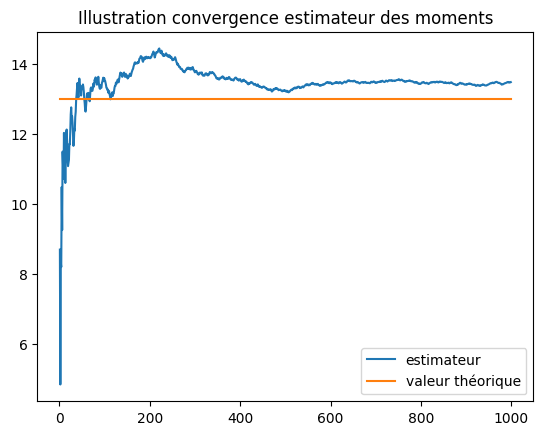

In [23]:
# Estimateur des moments 

N=np.arange(1,len(x))
E=[]
for i in N : 
    e=2*np.mean(x[:i])
    E.append(e) 
T=13*np.ones(len(N)) # valeur de theta
plt.plot(N,E,label='estimateur') 
plt.plot(N,T,label='valeur théorique')
plt.title('Illustration convergence estimateur des moments')
plt.legend()
plt.show()

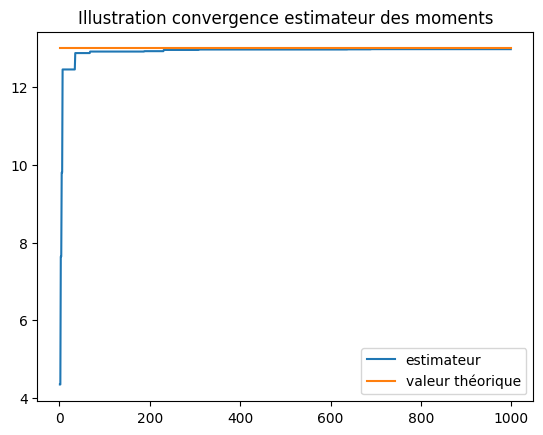

In [27]:
# EMV

N=np.arange(1,len(x))
E=[]
for i in N : 
    e=max(x[:i])
    E.append(e) 
T=13*np.ones(len(N)) # valeur de theta
plt.plot(N,E,label='estimateur') 
plt.plot(N,T,label='valeur théorique')
plt.title('Illustration convergence EMV')
plt.legend()
plt.show()

Pour la vitesse de convergence : 
- pour l'estimateur des moments, le TCL nous donne :
$$ \frac{\sqrt n}{2} ( \bar{\theta}_n - \theta) \xrightarrow[n \to \infty]{\mathcal L } \mathcal{N}\left(0,\frac{\theta^2}{12}\right).$$

- pour l'EMV :
$$ \mathbb{P}_\theta(n^\alpha(\theta - \hat{\theta}_n) \le t) = \mathbb{P}_\theta\left(\hat{\theta}_n \ge \theta - \frac{t}{n^\alpha} \right) = 1 - \mathbb{P}_\theta\left(\max_{1 \le i \le n} X_i \le \theta - \frac{t}{n^\alpha}  \right) = 1-  \mathbb{P}_\theta\left(X_1 \le \theta - \frac{t}{n^\alpha} \right)^n = 1 - \left( 1 - \frac{t}{n^\alpha \theta} \right)^n,$$
donc pour $\alpha = 1$,
$$\mathbb{P}_\theta(n^\alpha(\theta - \hat{\theta}_n)\le t) \xrightarrow[n \to \infty]{ } 1 - e^{- t/\theta},$$
c'est à dire 
$$ n^\alpha(\theta - \hat{\theta}_n)\xrightarrow[n \to \infty]{\mathcal L }  \mathcal E\left (\frac{1}{\theta} \right). $$

Illustrons ces convergences (pas demandé)

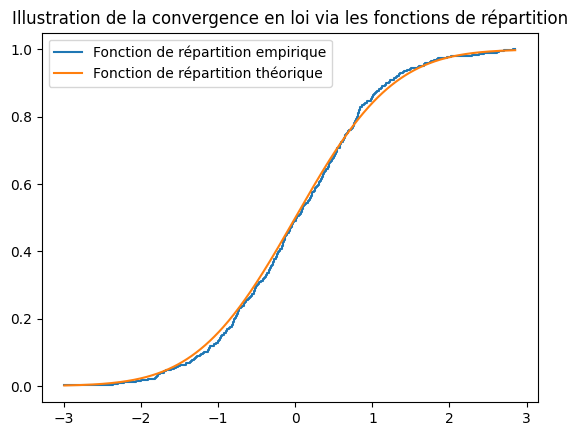

In [42]:
# Estimateur des moments 
theta=13
N=500
n=1000
M=stats.uniform.rvs(loc=0,scale=theta,size=(N,n))
E=(sqrt(12)/theta)*(sqrt(n)/2)*(2*np.mean(M, axis=1)-theta) 
E=np.sort(E)
F_emp=np.arange(1,N+1)/N
plt.plot(E,F_emp,drawstyle='steps-pre',label='Fonction de répartition empirique')
    
X = np.linspace(min(E),max(E),500)
F_th=stats.norm.cdf(X)  
plt.plot(X,F_th,label='Fonction de répartition théorique')
plt.title('Illustration de la convergence en loi via les fonctions de répartition')
plt.legend()
plt.show()

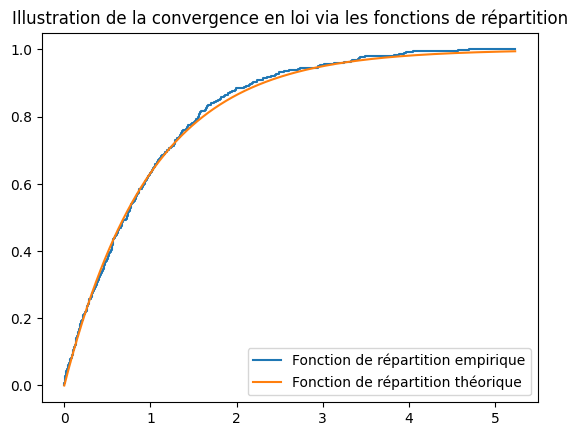

In [43]:
# EMV
theta=13
N=500
n=1000
M=stats.uniform.rvs(loc=0,scale=theta,size=(N,n))
E=(1/theta)*n*(theta-np.array([max(M[i]) for i in range (N)]))
E=np.sort(E)
F_emp=np.arange(1,N+1)/N
plt.plot(E,F_emp,drawstyle='steps-pre',label='Fonction de répartition empirique')
    
X = np.linspace(min(E),max(E),500)
F_th=stats.expon.cdf(X)  
plt.plot(X,F_th,label='Fonction de répartition théorique')
plt.title('Illustration de la convergence en loi via les fonctions de répartition')
plt.legend()
plt.show()

## Question 3 

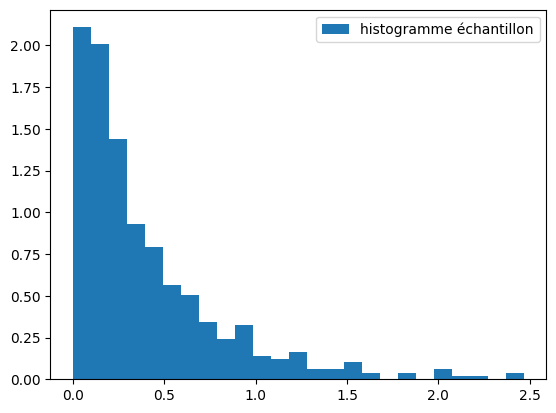

In [46]:
# Regardons l'histogramme que l'on obtient
theta=13
N=500
n=1000
M=stats.uniform.rvs(loc=0,scale=theta,size=(N,n))
E=sqrt(n)*(theta-np.array([max(M[i]) for i in range (N)]))
plt.hist(E,25,density='True', label='histogramme échantillon')
plt.title('Normalité asymptotique ?')
plt.legend()
plt.show()
# Cela ressemble assez peu à une loi normale... 

## Question 4 

Pour l'estimateur des moments, on a vu que l'on avait la convergence en loi suivante : 
$$ \frac{\sqrt{3 n}}{ \theta} ( \bar{\theta}_n - \theta) \xrightarrow[n \to \infty]{\mathcal L } \mathcal{N}\left(0,1\right),$$ 
or $\bar{\theta}_n$ est consistant (loi des grands nombres), et ainsi par le lemme de Slutsky, on obtient : 
$$ \frac{\sqrt{3 n}}{ \bar \theta_n } ( \bar{\theta}_n - \theta) \xrightarrow[n \to \infty]{\mathcal L } \mathcal{N}\left(0,1\right).$$
On en déduit 
$$\mathbb P \left ( \left |\frac{\sqrt{3 n}}{ \bar \theta_n} ( \bar{\theta}_n - \theta) \right |\le t_{1-\alpha/2} \right)  \xrightarrow[n \to \infty]{} 1 -\alpha, $$
et ainsi, un intervalle de confiance asymptotique de niveau $1 -\alpha$ est donné par : 
$$I_\alpha = \left [\bar \theta_n - \frac{\bar \theta_n}{\sqrt{3n}}t_{1-\alpha/2} \hspace{2pt}, \hspace{2pt}\bar \theta_n + \frac{\bar \theta_n}{\sqrt{3n}}t_{1-\alpha/2}\right ],  $$
où $t_{1-\alpha/2}$ est le quantile d'ordre $1-\alpha/2$ d'une loi normale centrée réduite. 

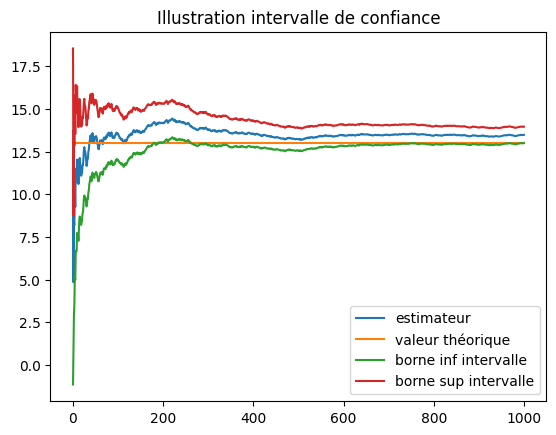

In [20]:
n=1000
alpha=0.05
N=np.arange(1,n)
E=[]
I_inf= []
I_sup=[]
t=stats.norm.ppf(1-alpha/2)
for i in N : 
    e=2*np.mean(x[:i])
    E.append(e) 
    I_inf.append(e- e*t/sqrt(3*i))
    I_sup.append(e+ e*t/sqrt(3*i))
T=13*np.ones(len(N)) # valeur de theta
plt.plot(N,E,label='estimateur') 
plt.plot(N,T,label='valeur théorique')
plt.plot(N,I_inf, label='borne inf intervalle')
plt.plot(N,I_sup, label='borne sup intervalle')
plt.title('Illustration intervalle de confiance')
plt.legend()
plt.show()

Pour l'EMV, on a vu que l'on avait la convergence en loi suivante : 
$$ \frac{n}{\theta}(\theta - \hat{\theta}_n )\xrightarrow[n \to \infty]{\mathcal L }  \mathcal E\left (1 \right), $$
or $\hat \theta_n$ est consistant (se montre à la main), et ainsi par le lemme de Slutsky, on obtient : 
$$ \frac{n}{\hat \theta_n}(\theta - \hat{\theta}_n)\xrightarrow[n \to \infty]{\mathcal L }  \mathcal E\left (1 \right). $$
On en déduit 
$$\mathbb P \left ( t_{\alpha/2} \le \frac{n}{\hat \theta_n}(\theta - \hat{\theta}_n) \le t_{1-\alpha/2}\right )  \xrightarrow[n \to \infty]{} 1 -\alpha,   $$
et ainsi, un intervalle de confiance asymptotique de niveau $1 -\alpha$ est donné par : 
$$I_\alpha = \left [\hat \theta_n + \frac{\hat \theta_n}{n}t_{\alpha/2} \hspace{2pt}, \hspace{2pt}\hat \theta_n + \frac{\hat \theta_n}{n}t_{1-\alpha/2}\right ],  $$
où $t_{\alpha/2}$ et $t_{1-\alpha/2}$ sont les quantiles d'ordre $\alpha /2 $ et $1-\alpha/2$ respectivement d'une exponentielle de paramètre $1$. 

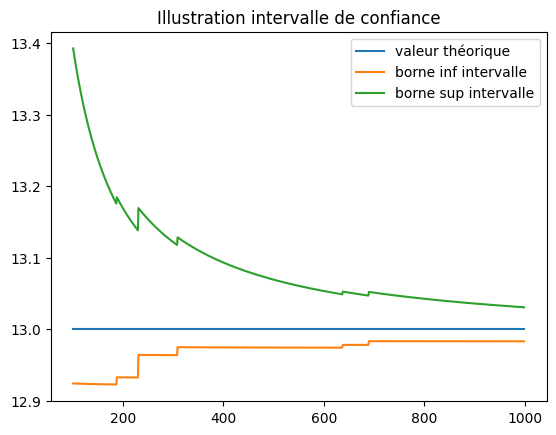

In [21]:
n=1000
alpha=0.05
N=np.arange(1,n)
I_inf= []
I_sup=[]
t1=stats.expon.ppf(alpha/2)
t2=stats.expon.ppf(1-alpha/2)
for i in N : 
    e=max(x[:i]) 
    I_inf.append(e+ e*t1/i)
    I_sup.append(e+ e*t2/i)
T=13*np.ones(len(N)) # valeur de theta
plt.plot(N[100:],T[100:],label='valeur théorique')
plt.plot(N[100:],I_inf[100:], label='borne inf intervalle')
plt.plot(N[100:],I_sup[100:], label='borne sup intervalle')
plt.title('Illustration intervalle de confiance')
plt.legend()
plt.show()

L'intervalle ne contient pas $\hat \theta_n$, mais a priori ce n'est pas choquant étant donné que $\theta $ est toujours supérieur ou égal à $\theta$... Mais perso, je trouve ça quand même plus cohérent de faire un intervalle asymétrique: 
On a
$$\mathbb P \left ( 0 \le \frac{n}{\hat \theta_n}(\theta - \hat{\theta}_n) \le t_{1-\alpha}\right )  \xrightarrow[n \to \infty]{} 1 -\alpha,   $$
et ainsi, l'intervalle 
$$I_\alpha = \left [\hat \theta_n \hspace{2pt}, \hspace{2pt}\hat \theta_n + \frac{\hat \theta_n}{n}t_{1-\alpha}\right ],  $$
est aussi un intervalle de confiance asymptotique de niveau $1-\alpha$, où $t_{\alpha}$ est le quantile d'ordre $1-\alpha$ d'une exponentielle de paramètre $1$. 


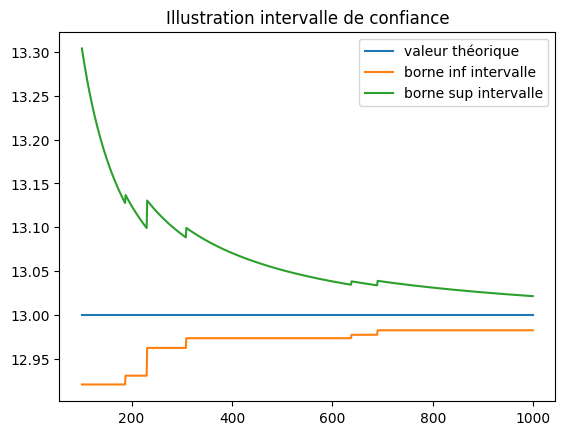

In [10]:
n=1000
alpha=0.05
N=np.arange(1,n)
I_inf= []
I_sup=[]
t=stats.expon.ppf(1-alpha)
for i in N : 
    e=max(x[:i])
    I_inf.append(e)
    I_sup.append(e+ e*t/i)
T=13*np.ones(len(N)) # valeur de theta
plt.plot(N[100:],T[100:],label='valeur théorique')
plt.plot(N[100:],I_inf[100:], label='borne inf intervalle')
plt.plot(N[100:],I_sup[100:], label='borne sup intervalle')
plt.title('Illustration intervalle de confiance')
plt.legend()
plt.show()

# Exercice 2 

## Question 1 

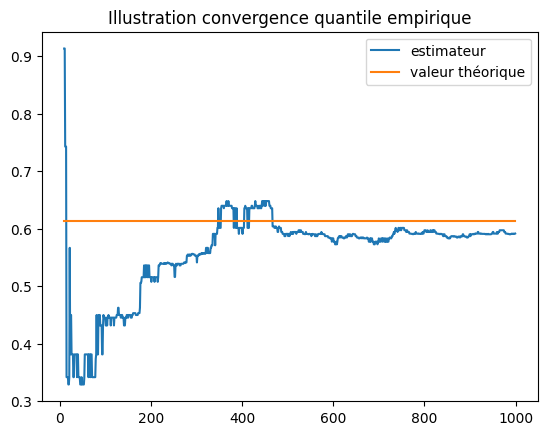

In [84]:
p=0.73 # celui de votre choix
q=stats.norm.ppf(p)
n=1000
N=np.arange(10,n)
X=stats.norm.rvs(size=n)
K=[]
for i in N : 
    x=np.sort(X[:i]) 
    k=x[floor(i*p)+1]
    K.append(k) 
T=q*np.ones(len(N)) # valeur de theta
plt.plot(N,K,label='estimateur') 
plt.plot(N,T,label='valeur théorique')
plt.title('Illustration convergence quantile empirique')
plt.legend()
plt.show()

## Question 2 

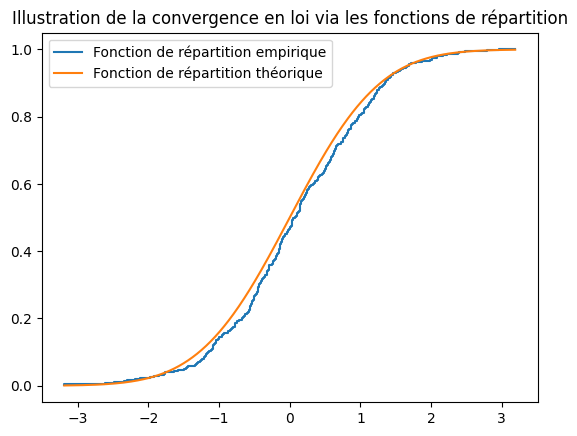

In [85]:
p=0.73 # celui de votre choix
q=stats.norm.ppf(p)
N=500
n=1000
sigma=p*(1-p)/(stats.norm.pdf(q)**2)
# Pour le coup je trouve ça plus facile avec une boucle for : 
E=[]
for _ in range(N): 
    X=np.sort(stats.norm.rvs(size=n))
    k=X[floor(n*p)+1]
    E.append(sqrt(n/sigma)*(k-q))
E=np.sort(E)
F_emp=np.arange(1,N+1)/N
plt.plot(E,F_emp,drawstyle='steps-pre',label='Fonction de répartition empirique')
    
X = np.linspace(min(E),max(E),500)
F_th=stats.norm.cdf(X)  
plt.plot(X,F_th,label='Fonction de répartition théorique')
plt.title('Illustration de la convergence en loi via les fonctions de répartition')
plt.legend()
plt.show()

# Exercice 3 

In [22]:
with open('donnees6.2.csv', newline='') as f:
    L=[ligne for ligne in csv.reader(f)][0]

x=np.array([eval(u) for u in L])

## Question 1 

On a : 
$$s_n := \sigma^{-2} \sum_{k=1}^n (X_k - m)^2 = \sum_{k=1}^n {\underbrace{\left( \frac{X_k -m}{\sigma} \right)}_{\sim \mathcal N (0,1)}}^2,$$
et ainsi $s_n$ suit une loi de $\chi^2$ à $n$ degrés de liberté. On a alors 
$$1-\alpha = \mathbb P \left ( t_{\alpha/2} \le s_n \le t_{1 - \alpha/2} \right ) = \mathbb P \left ( \frac{\sum_{k=1}^n (X_k - m)^2}{t_{1 - \alpha/2}} \le \sigma^2 \le\frac{\sum_{k=1}^n (X_k - m)^2}{t_{\alpha/2}} \right ), $$
où $t_{\alpha/2}$ et $t_{1-\alpha/2}$ sont les quantiles d'ordre $\alpha /2 $ et $1-\alpha/2$ respectivement d'une $\chi^2$ à $n$ degrés de liberté.  
Finalement, un intervalle de confiance NON ASYMPTOTIQUE de niveau $1-\alpha$ pour $\sigma$ est donné par : 
$$I_\alpha = \left [  \frac{\sum_{k=1}^n (X_k - m)^2}{t_{1 - \alpha/2}} \hspace{2pt}, \hspace{2pt} \frac{\sum_{k=1}^n (X_k - m)^2}{t_{\alpha/2}} \right ]. $$

In [23]:
# Pour l'échantillon : (la valeur théorique est 4)
alpha=0.05
m=1
s= np.sum((x-m)**2)
i_inf=s/stats.chi2.ppf(1-alpha/2, df=len(x))
i_sup=s/stats.chi2.ppf(alpha/2, df=len(x))
print(i_inf,i_sup)
# La valeur théorique est dedans ! 

3.875823424130405 4.61886397661635


In [111]:
# Illustration par la méthode de Monte-Carlo 
sigma=2
m=1
N=500
n=10 # NON ASYMPTOTIQUE, donc pas besoin de prendre n grand ! 
t1=stats.chi2.ppf(1-alpha/2, df=len(x))
t2=stats.chi2.ppf(alpha/2, df=len(x))
p=0
for _ in range(N): 
    x=stats.norm.rvs(loc=m,scale=sigma, size=n) 
    s= np.sum( (x-m)**2)
    i_inf=s/t1
    i_sup=s/t2
    p+=1*(i_inf <= sigma**2 <= i_sup)
print(p/N)
# On doit tomber sur 1-alpha 

0.958


## Question 2 

La variable 
$$S_n= \sigma^{-2} \sum_{k=1}^n (X_k - \bar X_n)^2$$
suit une loi du $\chi^2$ à $n-1$ degrés de liberté (théorème de Fisher, cf complément variables gaussiennes). 
On a alors 
$$1-\alpha = \mathbb P \left ( t_{\alpha/2} \le S_n \le t_{1 - \alpha/2} \right ) = \mathbb P \left ( \frac{\sum_{k=1}^n (X_k - \bar X_n)^2}{t_{1 - \alpha/2}} \le \sigma^2 \le\frac{\sum_{k=1}^n (X_k - \bar X_n)^2}{t_{\alpha/2}} \right ), $$
où $t_{\alpha/2}$ et $t_{1-\alpha/2}$ sont les quantiles d'ordre $\alpha /2 $ et $1-\alpha/2$ respectivement d'une $\chi^2$ à $n-1$ degrés de liberté.  
Finalement, un intervalle de confiance NON ASYMPTOTIQUE de niveau $1-\alpha$ pour $\sigma$ est donné par : 
$$I_\alpha = \left [  \frac{\sum_{k=1}^n (X_k - \bar X_n)^2}{t_{1 - \alpha/2}} \hspace{2pt}, \hspace{2pt} \frac{\sum_{k=1}^n (X_k - \bar X_n)^2}{t_{\alpha/2}} \right ]. $$

In [121]:
# Pour l'échantillon : 
alpha=0.05
m=np.mean(x)
s= np.sum((x-m)**2)
i_inf=s/stats.chi2.ppf(1-alpha/2, df=len(x))
i_sup=s/stats.chi2.ppf(alpha/2, df=len(x))
print(i_inf,i_sup)
# La valeur théorique est dedans ! 

3.8755944154593194 4.618591064312186


In [136]:
# Illustration par la méthode de Monte-Carlo 
sigma=2
m=1
N=500
n=10 # NON ASYMPTOTIQUE, donc pas besoin de prendre n grand ! 
t1=stats.chi2.ppf(1-alpha/2, df=len(x))
t2=stats.chi2.ppf(alpha/2, df=len(x))
p=0
for _ in range(N): 
    x=stats.norm.rvs(loc=m,scale=sigma, size=n) 
    mx=np.mean(x)
    s= np.sum((x-mx)**2)
    i_inf=s/t1
    i_sup=s/t2
    p+=1*(i_inf <= sigma**2 <= i_sup)
print(p/N)
# On doit tomber sur 1-alpha 

0.952


## Question 3 

La variable 
$$M_n := \sqrt{n(n-1)}\frac{\bar X_n -m }{\sqrt{\sum_{k=1}^n (X_k -\bar X_n)^2}}= \frac{\sqrt{n-1}}{\sqrt n}  \frac{\sum_{k=1}^n (X_k -m)}{\sqrt{\sum_{k=1}^n (X_k -\bar X_n)^2}} = \frac{\frac{\sqrt n}{n\sigma}\sum_{k=1}^n(X_k-m)}{\sigma^{-1}\sqrt{\frac{1}{n-1}\sum_{k=1}^n(X_k-\bar X_n)^2}} $$
suit une loi de Student à $k-1$ degrés de liberté (théroème de Fisher de nouveau). 
On a alors 
$$1-\alpha = \mathbb P \left ( t_{1 - \alpha/2} \le M_n \le t_{1 - \alpha/2} \right ) = \mathbb P \left ( \bar X_n - t_{1-\alpha/2}\frac{ \sqrt{\sum_{k=1}^n (X_k - \bar X_n)^2 }}{\sqrt{n(n-1)}} \le m \le \bar X_n + t_{1-\alpha/2}\frac{ \sqrt{\sum_{k=1}^n (X_k - \bar X_n)^2 }}{\sqrt{n(n-1)}} \right ), $$
où $t_{1- \alpha/2}$ est le quantile d'ordre $1-\alpha/2$ d'une Student à $k-1$ degrés de liberté. 
Finalement, un intervalle de confiance NON ASYMPTOTIQUE de niveau $1-\alpha$ pour $\sigma$ est donné par : 
$$I_\alpha = \left [  \bar X_n - t_{1-\alpha/2}\frac{ \sqrt{\sum_{k=1}^n (X_k - \bar X_n)^2 }}{\sqrt{n(n-1)}} \hspace{2pt}, \hspace{2pt} \bar X_n + t_{1-\alpha/2}\frac{ \sqrt{\sum_{k=1}^n (X_k - \bar X_n)^2 }}{\sqrt{n(n-1)}} \right ]. $$

In [139]:
# Pour l'échantillon : 
alpha=0.05
n=len(x)
m=np.mean(x)
s= sqrt(np.sum((x-m)**2))
t=stats.t.ppf(1-alpha/2, n-1)
i_inf=m-t*s/sqrt(n*(n-1))
i_sup=m+t*s/sqrt(n*(n-1))
print(i_inf,i_sup)
# La valeur théorique est dedans ! 

0.8566245858199324 1.1117835148106827


In [154]:
# Illustration par la méthode de Monte-Carlo 
sigma=2
m=1
N=500
n=10 # NON ASYMPTOTIQUE, donc pas besoin de prendre n grand ! 
t=stats.t.ppf(1-alpha/2, n-1)
p=0
for _ in range(N): 
    x=stats.norm.rvs(loc=m,scale=sigma, size=n) 
    mx=np.mean(x)
    sx=sqrt(np.sum((x-mx)**2))
    i_inf=mx-t*sx/sqrt(n*(n-1))
    i_sup=mx+t*sx/sqrt(n*(n-1))
    p+=1*(i_inf <= m <= i_sup)
print(p/N)
# On doit tomber sur 1-alpha 

0.954


# Exercice 4

## Question 1 

La vraisemblance du modèle est donnée, pour $x_1,\dots,x_n \ge 0$, par : 
$$L_{x_1,\dots,x_n}(\theta) = \prod_{i=1}^n \lambda e^{-\lambda x_i}= \lambda^n \exp \left (- \lambda \sum_{i=1}^n x_i \right ), $$
la log vraisemblance est ainsi donnée par : 
$$l_{x_1,\dots,x_n}(\theta)= n \ln(\lambda) - \lambda \sum_{i=1}^n x_i,$$
et alors : 
$$l_{x_1,\dots,x_n}'(\theta)= \frac{n}{\lambda} - \sum_{i=1}^n x_i. $$
L'estimateur par maximum de vraisemblance est donc : 
$$\hat \lambda_n := \frac{n}{\sum_{i=1}^n X_i}.$$
Il s'agit bien d'un maximum car la fonction est concave. On remarque qu'il coïncide avec l'estimateur obtenu avec la méthode des moments. 

In [166]:
# Pour les données : 
with open('donnees6.3.csv', newline='') as f:
    L=[ligne for ligne in csv.reader(f)][0]

x=np.array([eval(u) for u in L])

print(1/np.mean(x))
# La valeur théorique est 1/2. 

0.4796402075857638


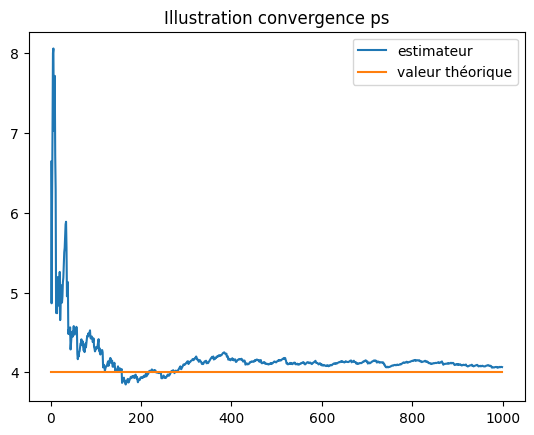

In [204]:
# Illustration de sa forte consistance 
n=1000
l=4
X=stats.expon.rvs(scale=1/l,size=n)
N=np.arange(1,n)
E=[]
for i in N : 
    e=1/np.mean(X[:i])
    E.append(e) 
T=l*np.ones(len(N)) 
plt.plot(N,E,label='estimateur') 
plt.plot(N,T,label='valeur théorique')
plt.title('Illustration convergence ps')
plt.legend()
plt.show()

## Questions 2 et 3

Si $X_1$ suit une loi exponentielle de paramètre $\lambda$, alors $\lambda X_1$ suit une loi exponentielle de paramètre $1$. Ainsi 
$\lambda\sum_{k=1}^n X_i$ suit une loi gamma de paramètre $(n,1)$, cela va nous suffire à obtenir un intervalle de confiance. (On aurait pu parler de loi gamma inverse, mais autant travailler avec les lois classiques que l'on connait bien.) Si l'on note $t_{\alpha/2}$ et $t_{1-\alpha/2}$ les quantiles d'ordre $\alpha /2 $ et $1-\alpha/2$ respectivement d'une telle loi gamma, alors on a : 
$$1-\alpha = \mathbb P \left (t_{\alpha/2} \le \lambda\sum_{k=1}^n X_i \le t_{1-\alpha/2} \right) = \mathbb P \left ( \frac{\hat \lambda_n t_{\alpha/2}}{n} \le  \lambda \le \frac{\hat \lambda_n t_{1-\alpha/2}}{n} \right).  $$
Et ainsi un intervalle de confiance NON ASYMPTOTIQUE de niveau $1-\alpha$ pour $\lambda$ est donné par : 
$$I_\alpha = \left [ \frac{\hat \lambda_n t_{\alpha/2}}{n}  \hspace{2pt},  \hspace{2pt} \frac{\hat \lambda_n t_{1-\alpha/2}}{n}  \right ].$$

In [167]:
# Pour les données : 
n=len(x)
t1=stats.gamma.ppf(alpha/2,a=n,loc=0,scale=1)
t2=stats.gamma.ppf(1-alpha/2,a=n,loc=0,scale=1)
ln=n/np.sum(x)
i_inf=ln*t1/n
i_sup=ln*t2/n
print(i_inf,i_sup)
# La valeur théorique est dedans ! 

0.4503692134664982 0.5098197216208042


In [161]:
# Illustration par la méthode de Monte-Carlo 
l=3
N=500
n=10 # NON ASYMPTOTIQUE, donc pas besoin de prendre n grand ! 
t1=stats.gamma.ppf(alpha/2,a=n,loc=0,scale=1)
t2=stats.gamma.ppf(1-alpha/2,a=n,loc=0,scale=1)
p=0
for _ in range(N): 
    x=stats.expon.rvs(scale=1/l, size=n) 
    ln=n/np.sum(x)
    i_inf=ln*t1/n
    i_sup=ln*t2/n
    p+=1*(i_inf <= l <= i_sup)
print(p/N)

0.954


# Exercice 5 

## Question 1 

On note $X_1, Y_1$ et $X_2, Y_2$ les coordonnées respectives de $A$ et $B$. Toutes ces variables suivent une loi uniforme sur $[0,1]$, et on a alors : 
$$ I:= \mathbb E (X) = \mathbb E \left(\sqrt{ (X_1-X_2)^2 + (Y_1 -Y_2)^2)} \right)= \int_{[0,1]^4} \sqrt{ (x_1-x_2)^2 + (y_1 -y_2)^2)} d x_1 d x_2 dy_1 dy_2. $$

## Question 2 

On veut estimer $I=\mathbb E(X)$. Pour cela, on utilise la méthode de Monte-Carlo (qui découle juste de la loi des grands nombres) et on estime $I$ par : 
$$\bar X_n = \frac 1 n \sum_{i=1}^n D_i,$$
où les $(D_i)_{1 \le i \le n}$ sont des variables données par la distance de variables $(A_i,B_i)_{1 \le i \le n}$ suivant une loi uniforme sur $[0,1]^2$. 

In [193]:
n=1000
D=0
for _ in range (n): 
    A=stats.uniform.rvs(loc=0,scale=1,size=2)
    B=stats.uniform.rvs(loc=0,scale=1,size=2)
    D+=np.linalg.norm(A-B)
print(D/N)

0.5228821356974446


## Question 3 

Le théorème central limite nous donne : 
$$ \frac{\sqrt n}{\sqrt{\mathbb E (X^2) - \mathbb E(X)^2}}(\bar X_n -\mathbb E (X)) \xrightarrow[n \to \infty]{\mathcal L } \mathcal{N}\left(0,1\right). $$ 
Or l'estimateur $\bar X_n$ est consistant (par la loi des grands nombres) donc d'après le lemme de Slutsky, on obtient : 
$$ \frac{\sqrt n}{\sqrt{|\mathbb E (X^2) - \bar X_n^2|}}(\bar X_n -\mathbb E (X)) \xrightarrow[n \to \infty]{\mathcal L } \mathcal{N}\left(0,1\right). $$ 
On en déduit 
$$\mathbb P \left ( t_{1 -\alpha/2} \le\frac{\sqrt n}{\sqrt{|\mathbb E (X^2) - \bar X_n^2|}}(\bar X_n -\mathbb E (X)) \le t_{1-\alpha/2}\right )  \xrightarrow[n \to \infty]{} 1 -\alpha,   $$
et ainsi, un intervalle de confiance asymptotique pour $I$ de niveau $1 -\alpha$ est donné par : 
$$I_\alpha = \left [ \bar X_n -\frac{\sqrt{|\mathbb E (X^2) - \bar X_n^2|}}{\sqrt n}t_{1 -\alpha/2} \hspace{2pt}, \hspace{2pt}\bar X_n +\frac{\sqrt{|\mathbb E (X^2) - \bar X_n^2|}}{\sqrt n}t_{1 -\alpha/2}\right ],  $$
où $t_{1-\alpha/2}$ est le quantile d'ordre $1-\alpha/2$ d'une normale centrée réduite.

In [195]:
n=1000
D=0
for _ in range (n): 
    A=stats.uniform.rvs(loc=0,scale=1,size=2)
    B=stats.uniform.rvs(loc=0,scale=1,size=2)
    D+=np.linalg.norm(A-B)
d=D/N
t=stats.norm.ppf(1-alpha/2)
i_inf=d-t*sqrt((1/3)-d**2)/sqrt(n)
i_sup=d+t*sqrt((1/3)-d**2)/sqrt(n)
print(i_inf,i_sup)

0.5058713757692321 0.5366432248404347


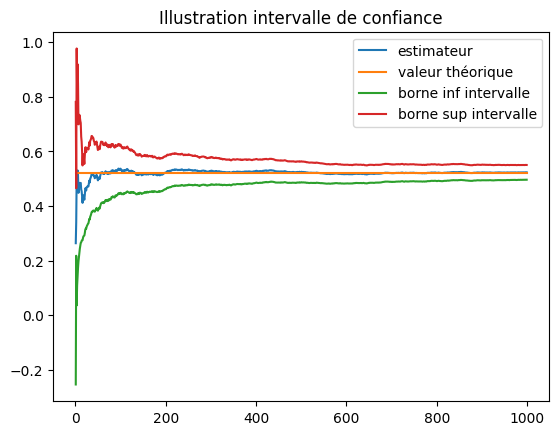

In [16]:
# Petite illustration de la forte consistance de l'estimateur et de l'intervalle de confiance 
n=1000
alpha=0.05
I=0.5214
D=[]
for _ in range (n): 
    A=stats.uniform.rvs(loc=0,scale=1,size=2)
    B=stats.uniform.rvs(loc=0,scale=1,size=2)
    D.append(np.linalg.norm(A-B))
N=np.arange(1,n)
E=[]
I_inf= []
I_sup=[]
t=stats.norm.ppf(1-alpha/2)
for i in N : 
    e=np.mean(D[:i])
    E.append(e) 
    I_inf.append(e- t*sqrt(abs((1/3)-e))/sqrt(i))
    I_sup.append(e+ t*sqrt(abs((1/3)-e))/sqrt(i))
T=I*np.ones(len(N)) 
plt.plot(N,E,label='estimateur') 
plt.plot(N,T,label='valeur théorique')
plt.plot(N,I_inf, label='borne inf intervalle')
plt.plot(N,I_sup, label='borne sup intervalle')
plt.title('Illustration intervalle de confiance')
plt.legend()
plt.show()

# Exercice 6

## Question 1 

Pour $x_1,\dots,x_n$ dans $\{0,1\}$, la vraisemblance du modèle est donnée par : 
$$L_{x_1,\dots,x_n}(p)= \prod_{i=1}^n p^{x_i}(1-p)^{1-x_i}= p^{\sum_{i=1}^n x_i}(1-p)^{n - \sum_{i=1}^n x_i},$$
et la log-vraisemblance est donc donnée par : 
$$l_{x_1,\dots,x_n}(p)= \ln(p) \sum_{i=1}^n x_i + \ln(1-p)\left (n - \sum_{i=1}^n x_i \right ), $$
et alors : 
$$l_{x_1,\dots,x_n}'(p)= \frac{\sum_{i=1}^n x_i}{p} - \frac{n - \sum_{i=1}^n x_i}{1-p} = \frac{(1-p)\sum_{i=1}^n x_i - np +p \sum_{i=1}^n x_i}{p(1-p)} = \frac{ \sum_{i=1}^n x_i - np}{p(1-p)}. $$
Finalement, l'estimateur de maximum de vraisemblance est donné par : 
$$\bar X_n = \frac{1}{n} \sum_{i=1}^n X_i,$$
il coïncide avec l'estimateur donné par la méthode des moments. 

In [169]:
# Pour les données : 
with open('donnees6.4.csv', newline='') as f:
    L=[ligne for ligne in csv.reader(f)][0]

x=np.array([eval(u) for u in L])

print(np.mean(x))
# La valeur théorique est 0,3. 

0.292


## Question 2 

Pour construire un intervalle de confiance asymptotique, on va utiliser le TCL. Ce dernier nous fournit la convergence en loi suivante : 
$$ \frac{\sqrt n}{\sqrt{p(1-p)}}(\bar X_n -p) \xrightarrow[n \to \infty]{\mathcal L } \mathcal{N}\left(0,1\right). $$ 
Or l'estimateur $\bar X_n$ est consistant (par la loi des grands nombres), donc d'après le lemme de Slutsky, on obtient : 
$$ \frac{\sqrt n}{\sqrt{\bar X_n(1-\bar X_n)}}(\bar X_n -p) \xrightarrow[n \to \infty]{\mathcal L } \mathcal{N}\left(0,1\right). $$ 
On en déduit 
$$\mathbb P \left ( t_{1 -\alpha/2} \le \frac{\sqrt n}{\sqrt{\bar X_n(1-\bar X_n)}}(\bar X_n -p) \le t_{1-\alpha/2}\right )  \xrightarrow[n \to \infty]{} 1 -\alpha,   $$
et ainsi, un intervalle de confiance asymptotique de niveau $1 -\alpha$ est donné par : 
$$I_\alpha = \left [ \bar X_n -\frac{\sqrt{\bar X_n(1-\bar X_n)}}{\sqrt n}t_{1 -\alpha/2} \hspace{2pt}, \hspace{2pt}\bar X_n +\frac{\sqrt{\bar X_n(1-\bar X_n)}}{\sqrt n}t_{1 -\alpha/2}\right ],  $$
où $t_{1-\alpha/2}$ est le quantile d'ordre $1-\alpha/2$ d'une normale centrée réduite. 

In [172]:
# Pour les données : 
n=len(x)
t=stats.norm.ppf(1-alpha/2)
p=np.mean(x)
i_inf=p-t*sqrt(p*(1-p))/sqrt(n)
i_sup=p+t*sqrt(p*(1-p))/sqrt(n)
print(i_inf,i_sup)
# La valeur théorique est dedans ! 

0.2638190165048304 0.32018098349516955


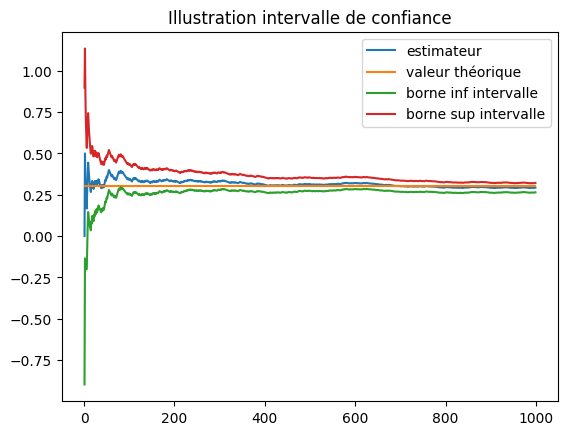

In [27]:
# Petite illustration de la forte consistance de l'estimateur et de l'intervalle de confiance 
n=1000
alpha=0.05
p=0.3
x=stats.binom.rvs(n=1,p=p,size=n)
N=np.arange(1,n)
E=[]
I_inf= []
I_sup=[]
t=stats.norm.ppf(1-alpha/2)
for i in N : 
    e=np.mean(x[:i])
    E.append(e) 
    I_inf.append(e- t*sqrt(p*(1-p))/sqrt(i))
    I_sup.append(e+ t*sqrt(p*(1-p))/sqrt(i))
T=p*np.ones(len(N)) 
plt.plot(N,E,label='estimateur') 
plt.plot(N,T,label='valeur théorique')
plt.plot(N,I_inf, label='borne inf intervalle')
plt.plot(N,I_sup, label='borne sup intervalle')
plt.title('Illustration intervalle de confiance')
plt.legend()
plt.show()

# Exercice 7

## Question 1 et 2 

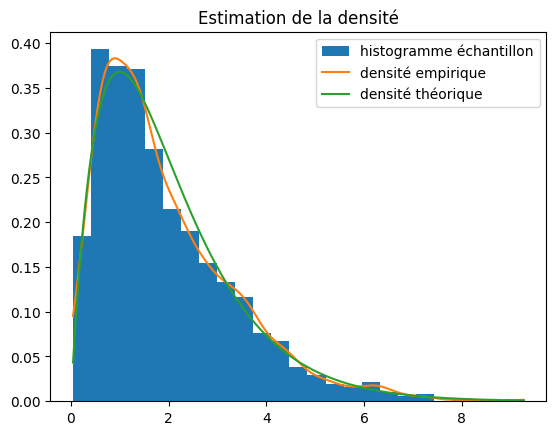

In [179]:
with open('donnees6.5.csv', newline='') as f:
    L=[ligne for ligne in csv.reader(f)][0]

X=np.array([eval(u) for u in L])

#je le fais avec le noyau gaussien pour plus de practicité
def f(x): 
    n=len(X)
    eps=n**(-1/5)
    Y=stats.norm.pdf((X-x)/eps)
    e=np.mean(Y)/eps 
    return(e) 
f=np.vectorize(f)

T=np.linspace(min(X),max(X),200)
plt.hist(X,25,density=True,label='histogramme échantillon')
plt.plot(T,f(T),label='densité empirique ')
plt.plot(T,stats.gamma.pdf(T,a=2),label='densité théorique') # j'ai lu l'avenir dans les cartes qui m'ont dit qu'il s'agissait d'une loi gamma 
plt.title('Estimation de la densité')
plt.legend()
plt.show()
